Importing the Dependencies

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Collection and Preparation

In [67]:
# load the data from the csv file into a pandas dataframe
titanic_data = pd.read_csv('/content/train.csv')

In [68]:
# number of rows and columns
titanic_data.shape

(891, 12)

In [69]:
# the first 5 rows of the data
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
# info about the data/columns
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [71]:
# checking for null entries
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [72]:
titanic_data.Cabin.value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [73]:
# fill the missing values --> numerical column with mean and categorical with the most common entry
titanic_data.fillna({'Age':np.mean(titanic_data.Age),'Cabin':titanic_data.Cabin.value_counts().idxmax(), 'Embarked':titanic_data.Embarked.value_counts().idxmax()}, inplace=True)


In [74]:
titanic_data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [75]:
# statistical measures of the data/columns
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [76]:
len(titanic_data.Name)

891

In [77]:
titanic_data.drop('Name', axis=1, inplace=True)

In [78]:
# converting the categorical columns to numbers--> encoding them
cat_cols = titanic_data.select_dtypes('object')

for col in cat_cols:
  titanic_data[col] = titanic_data[col].astype('category').cat.codes


In [79]:
titanic_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,1,22.0,1,0,523,7.2500,145,2
1,2,1,1,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,0,26.0,0,0,669,7.9250,145,2
3,4,1,1,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,1,35.0,0,0,472,8.0500,145,2


In [80]:
titanic_data.drop('PassengerId', axis=1, inplace=True)

In [81]:
titanic_data.Survived.value_counts()

,count
Survived,
0,549
1,342


Survived

0 --> Did not survive

1 --> Survived

In [82]:
#CORRELATION
correlation = titanic_data.corr()

Text(0.5, 1.0, 'Correlations')

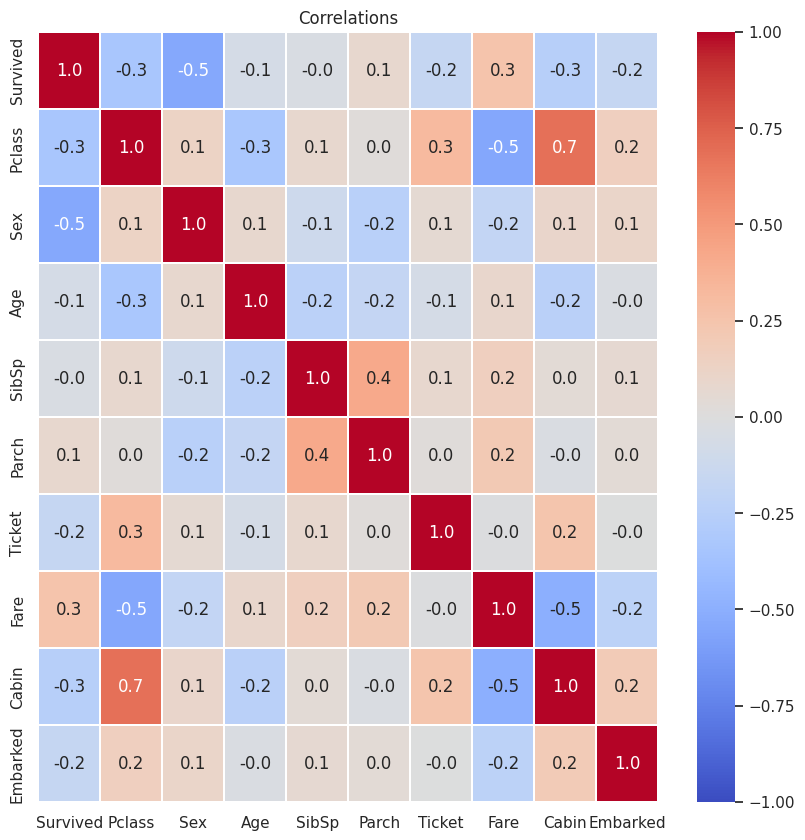

In [83]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, linecolor='white', linewidth=.2,annot=True, fmt='.1f', center=0, vmin=-1,cmap='coolwarm')
plt.title('Correlations')

([<matplotlib.axis.XTick at 0x792ff098bf50>,
 [Text(0, 0, 'Female'), Text(1, 0, 'Male')])

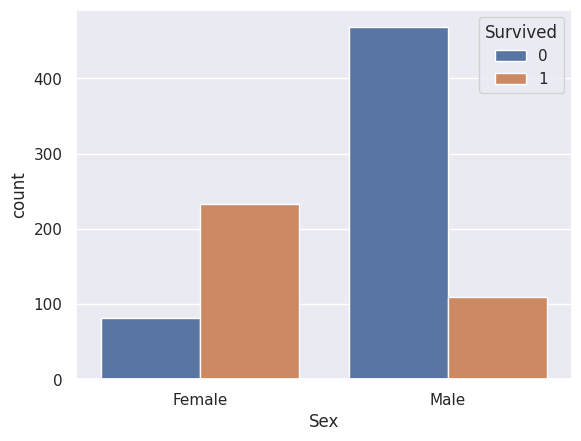

In [84]:
sns.set()
sns.countplot(x='Sex', hue='Survived', data=titanic_data)
plt.xticks([0,1],['Female', 'Male'])

Separating the features and target

In [85]:
X = titanic_data.drop(['Survived','Ticket'], axis=1)
y = titanic_data.Survived

Separating the training data and test data

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=1)

Model Training

In [87]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV()
lassocv.fit(X_train, y_train)

LassoCV()

In [88]:
lassocv.score(X_test,y_test)

0.35325755337210096

In [89]:
from sklearn.linear_model import RidgeCV

ridgecv = RidgeCV()
ridgecv.fit(X_train,y_train)

RidgeCV()

In [90]:
ridgecv.score(X_test,y_test)

0.3490427751355888

In [91]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

<BarContainer object of 8 artists>

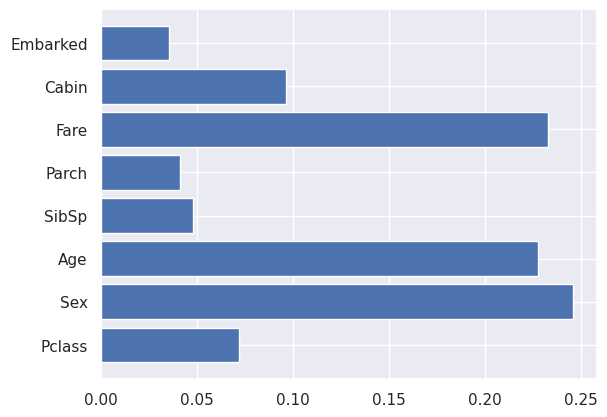

In [92]:
plt.barh(X_train.columns, rfc.feature_importances_)

<BarContainer object of 8 artists>

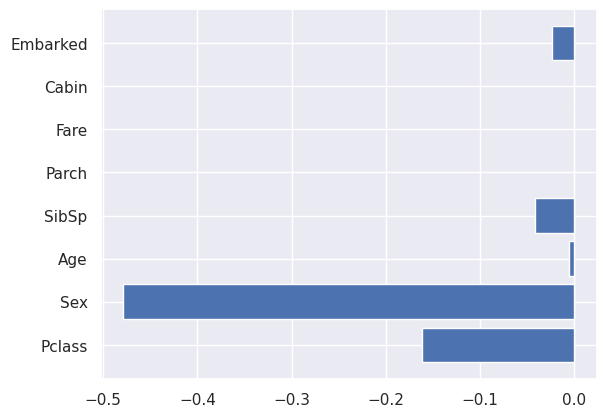

In [93]:
plt.barh(X_train.columns, lassocv.coef_)

In [95]:
accuracy_score(y_test, rfc.predict(X_test))

0.770949720670391

In [96]:
from sklearn import metrics

metrics.f1_score(y_test, rfc.predict(X_test))

0.6821705426356589

In [97]:
metrics.precision_score(y_test, rfc.predict(X_test))

0.7857142857142857

In [98]:
metrics.recall_score(y_test, rfc.predict(X_test))

0.6027397260273972

The RFC model;
*   wrongly predicts 40% to have not survived
*   correctly predicts 78.57% to have survived

